In [96]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
#from collections import namedtuple
import math
import ast
from scipy.optimize import curve_fit
from scipy.stats import chisquare
from scipy import special
from scipy.optimize import minimize
import seaborn as sns
sns.set_style("whitegrid")
import shapely as shapely
from shapely.geometry import LineString

In [97]:
def SingleEscapeSort(dataframe):
    dataframe = dataframe.drop('Unnamed: 0', axis=1)
    # if b==True:
    #     dataframe = dataframe.drop('10', axis=1)
    col = dataframe.pop("NTD")
    col2 = dataframe.pop('EnergyV')
    col3 = dataframe.pop('ChannelV')
    col4 = dataframe.pop('Neighbors')
    dataframe.insert(9, col2.name, col2)
    dataframe.insert(15, col.name, col)
    dataframe.insert(10, col3.name, col3)
    dataframe.insert(14, col4.name, col4)
    
    dataframe3 = dataframe[(dataframe['Multiplicity'] == 2)]
    dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
    dataframe3['ChannelV']=dataframe3['ChannelV'].apply(ast.literal_eval)
    dataframe3['NTD']=dataframe3['NTD'].apply(ast.literal_eval)
    dataframe3['Neighbors']=dataframe3['Neighbors'].apply(ast.literal_eval)
    
    rid3 = []
    dataframe3=dataframe3.reset_index(drop=True)
    for i in range(len(dataframe3)):
        if (2070<= dataframe3.iloc[i,9][1]< 2130):
            rid3.append(i)
            
    dataframe3_2100 = dataframe3[dataframe3.index.isin(rid3)]
    dataframe3_2100=dataframe3_2100.reset_index(drop=True)
    
    return dataframe3_2100

def NTD_Sort(dataframe_1tonne_single):
    NTD_data = []
    no_NTD_data = []

    NTD_data = []

    for i in range(len(dataframe_1tonne_single)):
        for j in range(len(dataframe_1tonne_single.iloc[i,10])):
            if dataframe_1tonne_single.iloc[i,10][j] in dataframe_1tonne_single.iloc[i,17]:
                NTD_data.append(i) 

    NTD_data = dataframe_1tonne_single[dataframe_1tonne_single.index.isin(NTD_data)]
    NTD_data=NTD_data.reset_index(drop=True)

    for i in range(len(dataframe_1tonne_single)):
        for j in range(len(dataframe_1tonne_single.iloc[i,10])):
            if dataframe_1tonne_single.iloc[i,10][0] and dataframe_1tonne_single.iloc[i,10][1] not in dataframe_1tonne_single.iloc[i,17]:
                no_NTD_data.append(i) 

    no_NTD_data = dataframe_1tonne_single[dataframe_1tonne_single.index.isin(no_NTD_data)]
    no_NTD_data=no_NTD_data.reset_index(drop=True)
    
    return NTD_data, no_NTD_data

def Topology_Sort(no_NTD_data):
    F_NTD = []
    E_NTD = []
    N_NTD = []
    C_NTD = []
    for i in range(len(no_NTD_data)):
        if no_NTD_data.iloc[i,14][0][0] == 'F':
            F_NTD.append(i)
        elif no_NTD_data.iloc[i,14][0][0] == 'E':
            E_NTD.append(i)
        elif no_NTD_data.iloc[i,14][0][0] == 'N':
            N_NTD.append(i)
        elif no_NTD_data.iloc[i,14][0][0] == 'C':
            C_NTD.append(i)
        else:
            O_NTD.append(i)
            
    F_NTD = no_NTD_data[no_NTD_data.index.isin(F_NTD)]
    F_NTD=F_NTD.reset_index(drop=True)
    
    E_NTD = no_NTD_data[no_NTD_data.index.isin(E_NTD)]
    E_NTD=E_NTD.reset_index(drop=True)
    
    N_NTD = no_NTD_data[no_NTD_data.index.isin(N_NTD)]
    N_NTD=N_NTD.reset_index(drop=True)
    
    C_NTD = no_NTD_data[no_NTD_data.index.isin(C_NTD)]
    C_NTD=C_NTD.reset_index(drop=True)
    
    return F_NTD, E_NTD, C_NTD, N_NTD

def PrimarySecondarySplit(dataframe_1tonne_double):
    total_2100 = []
    total_511 = []

    for i in range(len(dataframe_1tonne_double)):
        total_511.append(dataframe_1tonne_double.iloc[i,9][0])
        total_2100.append(dataframe_1tonne_double.iloc[i,9][1])
        
    return np.asarray(total_2100), np.asarray(total_511)

In [5]:
dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
dataframe_single = SingleEscapeSort(dataframe)

NTD_single, no_NTD_single = NTD_Sort(dataframe_single)
F_NTD, E_NTD, C_NTD, N_NTD= Topology_Sort(NTD_single)
F, E, C, N= Topology_Sort(no_NTD_single)

NTD_2100, NTD_511 = PrimarySecondarySplit(NTD_single)

/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_32537/3028205152.py:1: DtypeWarning: Columns (27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_32537/3586459109.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
/var/folders/z8/n41n2zq134qgydj3s_285jqc0000gn/T/ipykernel_32537/3586459109.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documenta

In [133]:
def NormGuassianStepLinear(x,mu,sigma,f, A,d, E0, E1):
    Ec = (E0+E1)/2
    p = (1+A*(x-Ec))/(E1-E0)
    err_func = ((mu-E0)*special.erfc((E0-mu)/np.sqrt(2*np.pi*sigma**2))+(E1-mu)*special.erfc((E1-mu)/np.sqrt(2*np.pi*sigma**2))+np.sqrt(2*sigma**2)*(np.exp(-(mu-E0)**2/(2*np.pi*sigma**2))-np.exp(-(mu-E1)**2/(2*np.pi*sigma**2))))
    return (1-f-d)*(np.exp(-(x-mu)**2/(2*sigma**2)))/np.sqrt(2*np.pi*sigma**2)+f*p+(d*special.erfc((x-mu)/np.sqrt(2*np.pi*sigma**2)))/err_func

def NegLogLikelihoodGuassStepLinear(params,data):
    mu,sigma, f, A,d = params
    E0 = min(data)
    E1 = max(data)
    LogL = 0
    for k in data:
        x = NormGuassianStepLinear(k,mu,sigma,f, A,d, E0, E1)
        if x > 0:
            LogL += np.log(x)
    return -2*LogL

def MinimizeNegLogLikelihoodGuassStepLinear(data, initial_params):
    E0 = min(data)
    E1 = max(data)
    Ec = (E0+E1)/2
    bound_A = 1/(Ec-E0)
    result = minimize(NegLogLikelihoodGuassStepLinear, initial_params, args=(data),
                      method='Nelder-Mead',bounds=[(0, None), (0, None), (0,1), (-bound_A, bound_A), (0,1)])
    return result.x


def DerivativeLikelihood(data,param):
    actual_data=np.array(NegLogLikelihoodGuassStepLinear(param,data), dtype=float)
    intersection = None
    for i in param:
        if isinstance(i, float) == False:
            var = np.array(i,dtype=float)
            derSumLogL = np.gradient(actual_data,var)
            derivative = LineString(np.column_stack((var, derSumLogL)))
            xaxis = LineString(np.column_stack((var,np.linspace(0,0, len(var)))))
            intersection = derivative.intersection(xaxis)
    return intersection.x

Fitted Mean: 511.1432558071038
Fitted Standard Dev: 2.314581190318058
Fitted A: -0.006240517125891619
Fitted f: 0.39238637008693056
Fitted d: 0.008600963603563057


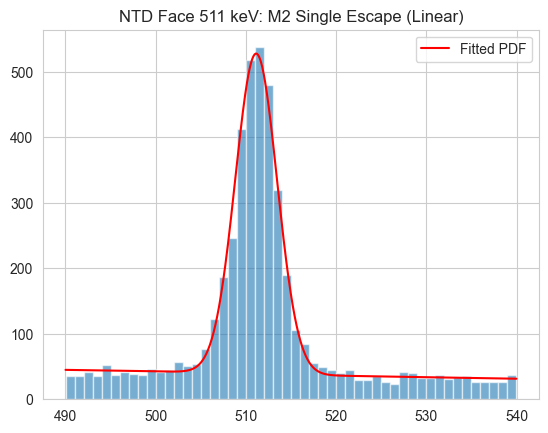

In [161]:
data = []

for i in NTD_511:
    if 490 <= i <= 540:
        data.append(i)

initial_parms = [5.11206318e+02,  2.20254997e+00,  0.3, 0.00438340732695856, 0.6]
mu_fit, sigma_fit, f_fit, A_fit, d_fit = MinimizeNegLogLikelihoodGuassStepLinear(data, initial_parms)
# print(f"Fitted parameters: {fitted_params}")
x_values = np.linspace(min(data), max(data), 1000)
bin_num = 50
bin_width = (max(x_values) - min(x_values))/bin_num

fitted_pdf = NormGuassianStepLinear(x_values, mu_fit, sigma_fit, f_fit, A_fit, d_fit, min(x_values), max(x_values))*len(data)/bin_width
plt.hist(data, bins=bin_num, alpha=0.6)
plt.plot(x_values, fitted_pdf, label='Fitted PDF', color='red')
# plt.plot(x_values, Err_Func(x_values, mu_fit, sigma_fit, d_fit, min(data), max(data))*(len(data)/bin_width), linestyle = '--', color='purple', label = 'Erf')

plt.legend()
plt.title('NTD Face 511 keV: M2 Single Escape (Linear)')
print('Fitted Mean: ' + str(mu_fit))
print('Fitted Standard Dev: ' + str(sigma_fit))
print('Fitted A: ' + str(A_fit))
print('Fitted f: ' + str(f_fit))
print('Fitted d: ' + str(d_fit))

In [132]:
goodness_of_fit = (NegLogLikelihoodGuassStepLinear([mu_fit,sigma_fit,f_fit,A_fit,d_fit], data))/(len(data) - 5+1)
print(goodness_of_fit)

-3.321056918774917


Fitted Mean: 511.1457876728296
Fitted Standard Dev: 2.3623378648676687
Fitted f: 0.45134989054332836
Fitted A: -0.009653624688418953
Fitted D/A: 1.6952896636490814e-07


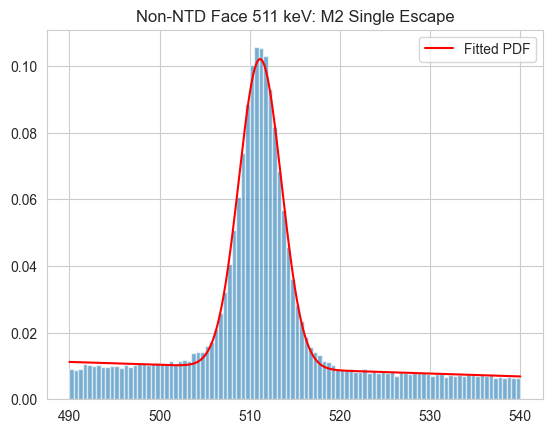

In [100]:
noNTD_2100, noNTD_511 = PrimarySecondarySplit(no_NTD_single)

dataNoNTD = []

for i in noNTD_511:
    if 490 <= i <= 540:
        dataNoNTD.append(i)

initial_parms = [5.11206318e+02,  2.20254997e+00,  0.3, 0.00438340732695856, 0.2]
noNTDmu_fit, noNTDsigma_fit, noNTDf_fit,noNTDA_fit ,noNTDd_fit = MinimizeNegLogLikelihoodGuassStepLinear(dataNoNTD, initial_parms)
# print(f"Fitted parameters: {fitted_params}")
x_values = np.linspace(min(dataNoNTD), max(dataNoNTD), 1000)
fitted_pdf = NormGuassianStepLinear(x_values, noNTDmu_fit, noNTDsigma_fit, noNTDf_fit, noNTDA_fit, noNTDd_fit, min(x_values), max(x_values))
plt.hist(dataNoNTD, bins=100, alpha=0.6, density=True)
plt.plot(x_values, fitted_pdf, label='Fitted PDF', color='red')
plt.legend()
plt.title('Non-NTD Face 511 keV: M2 Single Escape')
print('Fitted Mean: ' + str(noNTDmu_fit))
print('Fitted Standard Dev: ' + str(noNTDsigma_fit))
print('Fitted f: ' + str(noNTDf_fit))
print('Fitted A: ' + str(noNTDA_fit))
print('Fitted D/A: ' + str(noNTDd_fit))

In [128]:
goodness_of_fit = (NegLogLikelihoodGuassStepLinear([noNTDmu_fit,noNTDsigma_fit,noNTDf_fit,noNTDA_fit,noNTDd_fit], dataNoNTD))/(len(dataNoNTD) - 5+1)
print(goodness_of_fit)

6.819627091632971


In [101]:
F_2100, F_511 = PrimarySecondarySplit(F)
C_2100, C_511 = PrimarySecondarySplit(C)
N_2100, N_511 = PrimarySecondarySplit(N)
E_2100, E_511 = PrimarySecondarySplit(E)

F_511_cut = [i for i in F_511 if 490 <= i <= 540]
C_511_cut = [i for i in C_511 if 490 <= i <= 540]
N_511_cut = [i for i in N_511 if 490 <= i <= 540]
E_511_cut = [i for i in E_511 if 490 <= i <= 540]

In [102]:
F_initial_511= [5.11214209e+02,  2.39241791e+00,  1.58387483e+03/3.85014211e+04, 7.26182528e-03/3.85014211e+02, 0.2]
C_initial_511 = [5.11142240e+02,  2.18732146e+00,  2.56926028e+01/7.01755321e+02,2.86141255e-03/7.01755321e+01, 0.2]
N_initial_511 = [5.11125800e+02,  2.18277950e+00,  6.34140283e+02/1.60768994e+03,6.68469222e-03/1.60768994e+02, 0.2]
E_initial_511 = [5.11073460e+02,  2.15571423e+00,  4.36601701e+02/2.47286144e+03,6.04231908e-03/2.47286144e+02, 0.2]

Cmu_fit, Csigma_fit, Cf_fit, CA_fit, Cd_fit = MinimizeNegLogLikelihoodGuassStepLinear(C_511_cut, C_initial_511)
Emu_fit, Esigma_fit, Ef_fit, EA_fit, Ed_fit = MinimizeNegLogLikelihoodGuassStepLinear(E_511_cut, E_initial_511)
Nmu_fit, Nsigma_fit, Nf_fit, NA_fit, Nd_fit = MinimizeNegLogLikelihoodGuassStepLinear(N_511_cut, N_initial_511)
Fmu_fit, Fsigma_fit, Ff_fit, FA_fit, Fd_fit = MinimizeNegLogLikelihoodGuassStepLinear(F_511_cut, F_initial_511)

In [119]:
def Graph_2100(data, mu_fit, sigma_fit, f_fit, A_fit, d_fit):
    x_values = np.linspace(min(data), max(data), 1000)
    fitted_pdf = NormGuassianStepLinear(x_values, mu_fit, sigma_fit, f_fit, A_fit,d_fit, min(x_values), max(x_values))*len(data)
    return x_values, fitted_pdf

Fx, F_fit = Graph_2100(F_511_cut, Fmu_fit, Fsigma_fit, Ff_fit, FA_fit, Fd_fit)
Cx, C_fit = Graph_2100(C_511_cut, Cmu_fit, Csigma_fit, Cf_fit, CA_fit, Cd_fit)
Nx, N_fit = Graph_2100(N_511_cut, Nmu_fit, Nsigma_fit, Nf_fit, NA_fit, Nd_fit)
Ex, E_fit = Graph_2100(E_511_cut, Emu_fit, Esigma_fit, Ef_fit, EA_fit, Ed_fit)

Text(0.5, 1.0, 'E')

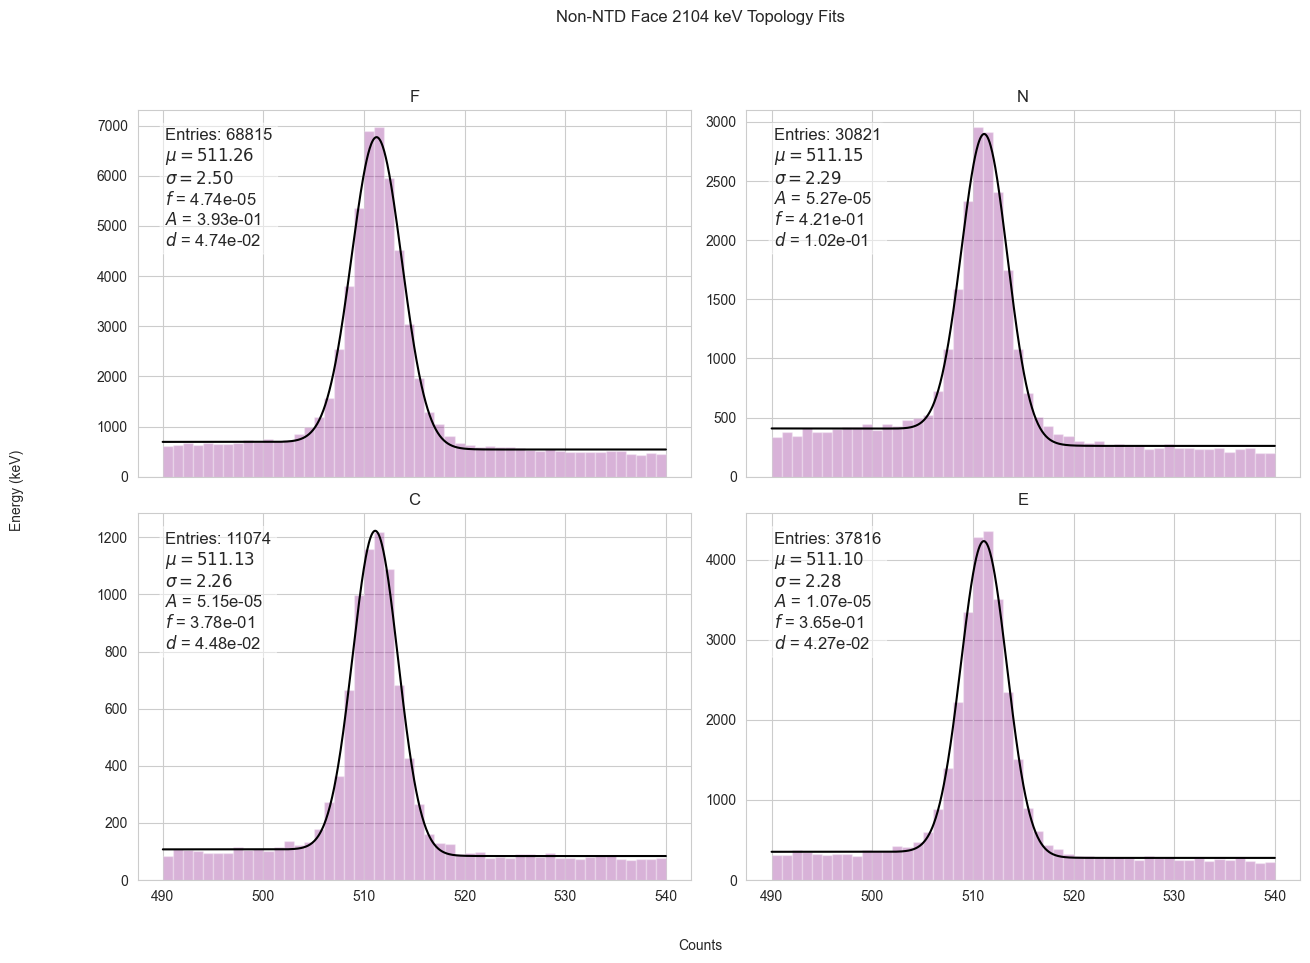

In [159]:
fig, ax = plt.subplots(2,2, sharex='col', figsize=(15, 10))
fig.text(0.04, 0.5, 'Energy (keV)', va='center', rotation = 'vertical')
fig.text(0.5, 0.04, 'Counts', ha='center')
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
fig.suptitle('Non-NTD Face 2104 keV Topology Fits')
plt.subplots_adjust(wspace=0.1, hspace=0.1)

textF = '\n'.join(('Entries: ' + (str(len(F_511_cut))),
    r'$\mu=%.2f$' % (Fmu_fit, ),
    r'$\sigma=%.2f$' % (Fsigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(FA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(Ff_fit, precision = 2), ),
r'$d$ = ' + str(np.format_float_scientific(Fd_fit, precision = 2))))

ax[0,0].plot(Fx, F_fit,label='F Fit', color='black')
ax[0,0].hist(F_511_cut, bins = 50 , color='purple', alpha=0.3)
ax[0,0].text(0.05, 0.95, textF, transform=ax[0,0].transAxes, fontsize=12,
        verticalalignment='top', bbox=props)
ax[0,0].set_title('F')
###########

textC = '\n'.join(('Entries: ' + str(len(C_511_cut, )),
    r'$\mu=%.2f$' % (Cmu_fit, ),
    r'$\sigma=%.2f$' % (Csigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(CA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(Cf_fit, precision = 2), ),
r'$d$ = ' + str(np.format_float_scientific(Cd_fit, precision = 2))))

ax[1,0].plot(Cx, C_fit,label='F Fit', color='black')
ax[1,0].hist(C_511_cut, bins = 50 , color='purple', alpha=0.3)
ax[1,0].text(0.05, 0.95, textC, transform=ax[1,0].transAxes, fontsize=12,
        verticalalignment='top', bbox=props)
ax[1,0].set_title('C')
#########

textN = '\n'.join(('Entries: '+  str(len(N_511_cut, )),
    r'$\mu=%.2f$' % (Nmu_fit, ),
    r'$\sigma=%.2f$' % (Nsigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(NA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(Nf_fit, precision = 2), ),
r'$d$ = ' + str(np.format_float_scientific(Nd_fit, precision = 2))))

ax[0,1].plot(Nx, N_fit,label='N Fit', color='black')
ax[0,1].hist(N_511_cut, bins = 50 , color='purple', alpha=0.3)
ax[0,1].text(0.05, 0.95, textN, transform=ax[0,1].transAxes, fontsize=12,
        verticalalignment='top', bbox=props)
ax[0,1].set_title('N')
########

textE = '\n'.join(('Entries: ' + str(len(E_511_cut, )),
    r'$\mu=%.2f$' % (Emu_fit, ),
    r'$\sigma=%.2f$' % (Esigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(EA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(Ef_fit, precision = 2), ),
r'$d$ = ' + str(np.format_float_scientific(Ed_fit, precision = 2))))

ax[1,1].plot(Ex, E_fit,label='E Fit', color='black')
ax[1,1].hist(E_511_cut, bins = 50 , color='purple', alpha=0.3)
ax[1,1].text(0.05, 0.95, textE, transform=ax[1,1].transAxes, fontsize=12,
        verticalalignment='top', bbox=props)
ax[1,1].set_title('E')

In [105]:
def NegLogLikelihoodGuassLinear(params,data):
    mu,sigma, b, C,d = params
    E0 = min(data)
    E1 = max(data)
    LogL = 0
    for k in data:
        x = NormGuassianStepLinear(k,mu,sigma,b,C,d, E0, E1)
        LogL += np.log(x)
    return -2*LogL

# def NegLogLikelihoodGuassStepExp(params,data):
#     mu,sigma, b, C,d = params
#     E0 = min(data)
#     E1 = max(data)
#     LogL = 0
#     LogLarr = []
#     for i in range(len(sigma)):
#         for k in data:
#             x = NormGuassianStepLinear(k,mu,sigma[i],b,C,d, E0, E1)
#             if x > 0:
#                 LogL += np.log(x)
#         LogLarr.append(-2*LogL)
#     return LogLarr

def Uncertainity(data, mu, sigma,b,c,d):
    params = [mu, sigma, b, c,d]
    arr1 = NegLogLikelihoodGuassLinear(params, data)
    arr2 = arr1 - min(arr1)
    xaxis = LineString(np.column_stack((arr2,np.linspace(1,1, len(arr2)))))
    if isinstance(mu, float) == False: 
        curve = LineString(np.column_stack((mu, arr2)))
        intersection = xaxis.intersection(curve)
        if str(intersection) == 'LINESTRING Z EMPTY':
            intersection_indices = np.where(np.isclose(arr2, np.linspace(1,1, len(arr2)), atol=0.05))[0]
            intersection = mu[intersection_indices]
    elif isinstance(mu, float) == True:
        curve = LineString(np.column_stack((sigma, arr2)))
        intersection = curve.intersection(xaxis)
        if str(intersection) == 'LINESTRING Z EMPTY':
            intersection_indices = np.where(np.isclose(arr2, np.linspace(1,1, len(arr2)), atol=0.5))[0]
            intersection = sigma[intersection_indices]
        # intersection_y = arr2[intersection_indices]
        # intersection = list(zip(intersection_x, intersection_y))
    return intersection, arr2

def Errors(mu_intersections, means):
    upper_errs = []
    lower_errs = []

    for i in range(len(mu_intersections)):
        if mu_intersections[i][0] < mu_intersections[i][1]:
            upper_errs.append(mu_intersections[i][1])
            lower_errs.append(mu_intersections[i][0])
        else:
            upper_errs.append(mu_intersections[i][0])
            lower_errs.append(mu_intersections[i][1])

    top_errs = []
    bot_errs = []
    for i in range(len(upper_errs)):
        top_errs.append(abs(means[i]-upper_errs[i]))
        bot_errs.append(abs(means[i]-lower_errs[i]))

    asymmetric_errormu = np.array(list(zip(bot_errs, top_errs))).T
    return asymmetric_errormu

In [134]:
Fmu_arr = np.linspace(Fmu_fit-1, Fmu_fit+5, 1000)
Cmu_arr = np.linspace(Cmu_fit-5, Cmu_fit+5, 100)
Nmu_arr = np.linspace(Nmu_fit-5, Nmu_fit+5, 100)
Emu_arr = np.linspace(Emu_fit-5, Emu_fit+5, 100)

Fintersection_mu, Ferror_mu = Uncertainity(F_511_cut, Fmu_arr, Fsigma_fit,Ff_fit,FA_fit, Fd_fit)
Cintersection_mu, Cerror_mu = Uncertainity(C_511_cut, Cmu_arr, Csigma_fit,Cf_fit,CA_fit, Cd_fit)
Nintersection_mu, Nerror_mu = Uncertainity(N_511_cut, Nmu_arr, Nsigma_fit,Nf_fit,NA_fit, Nd_fit)
Eintersection_mu, Eerror_mu = Uncertainity(E_511_cut, Emu_arr, Esigma_fit,Ef_fit,EA_fit, Ed_fit)

In [38]:
print(Fintersection_mu)

MULTIPOINT (511.18692959485196 1, 511.2199230630886 1)


In [107]:
Fsigma_arr = np.linspace(Fsigma_fit/2, Fsigma_fit*2, 1000)
Csigma_arr = np.linspace(Csigma_fit/2, Csigma_fit*2, 1000)
Esigma_arr = np.linspace(Esigma_fit/1.5, Esigma_fit*1.5, 1000)
Nsigma_arr = np.linspace(Nsigma_fit/1.5, Nsigma_fit*1.5, 1000)

Fintersection_sigma, Ferror_sigma = Uncertainity(F_511_cut, Fmu_fit, Fsigma_arr,Ff_fit,FA_fit, Fd_fit)
Cintersection_sigma, Cerror_sigma = Uncertainity(C_511_cut, Cmu_fit, Csigma_arr,Cf_fit,CA_fit, Cd_fit)
Nintersection_sigma, Nerror_sigma = Uncertainity(N_511_cut, Nmu_fit, Nsigma_arr,Nf_fit,NA_fit, Nd_fit)
Eintersection_sigma, Eerror_sigma = Uncertainity(E_511_cut, Emu_fit, Esigma_arr,Ef_fit,EA_fit, Ed_fit)

In [108]:
sigma_arr = np.linspace(sigma_fit/1.5, sigma_fit*1.5, 100)
intersection_sigma, error_sigma = Uncertainity(data, mu_fit, sigma_arr,f_fit,A_fit, d_fit)
noNTDsigma_arr = np.linspace(noNTDsigma_fit/1.5, noNTDsigma_fit*1.5, 1000)
noNTDintersection_sigma, noNTDerror_sigma = Uncertainity(dataNoNTD, noNTDmu_fit, noNTDsigma_arr,noNTDf_fit,noNTDA_fit,noNTDd_fit)

In [146]:
mu_arr = np.linspace(mu_fit-2, mu_fit+2, 1000)
intersection_mu, error_mu = Uncertainity(data, mu_arr, sigma_fit,f_fit,A_fit,d_fit)

KeyboardInterrupt: 

In [149]:
noNTDmu_arr = np.linspace(noNTDmu_fit-5, noNTDmu_fit+5, 3000)
noNTDintersection_mu, noNTDerror_mu = Uncertainity(dataNoNTD, noNTDmu_arr, noNTDsigma_fit, noNTDf_fit, noNTDA_fit, noNTDd_fit)

In [151]:
# plt.plot(noNTDmu_arr, noNTDerror_mu)
# plt.ylim(0,9)
# plt.axvline(noNTDintersection_mu.geoms[1].x, linestyle = '--', color='orange')
# plt.axvline(noNTDintersection_mu.geoms[0].x, linestyle = '--', color='r')
# plt.xlim(511,511.3)
# plt.ylabel(r'$\Delta\chi^2$')
# plt.xlabel('Means')
# print('Top Error:' + str(noNTDmu_fit - noNTDintersection_mu.geoms[1].x))
# print('Top Error:' + str(noNTDmu_fit - noNTDintersection_mu.geoms[0].x))
# print(Cerror_sigma)

Text(0.5, 1.0, 'M2 Single Escape: 511 keV Means')

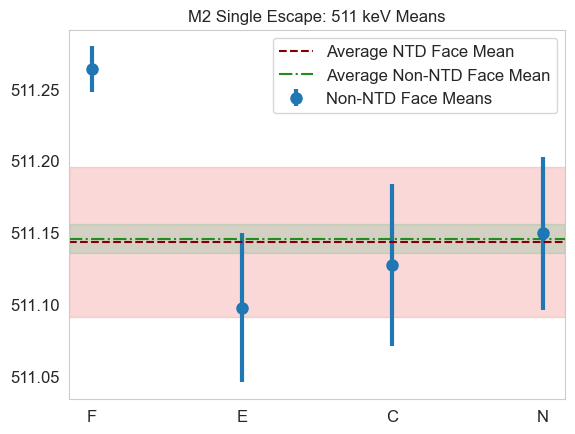

In [129]:
ax = plt.subplot()

topologies = ['F', 'E', "C", 'N']
means = [Fmu_fit, Emu_fit, Cmu_fit, Nmu_fit]
mu_intersections = [[Fintersection_mu.geoms[0].x, Fintersection_mu.geoms[1].x],[Eintersection_mu.geoms[0].x, Eintersection_mu.geoms[1].x],
                   [Cintersection_mu.geoms[0].x, Cintersection_mu.geoms[1].x], [Nintersection_mu.geoms[0].x,Nintersection_mu.geoms[1].x] ]

asymmetric_errormu = Errors(mu_intersections, means)

ax.errorbar(topologies, means, yerr=asymmetric_errormu, fmt='o', ms = 8, elinewidth=3, label='Non-NTD Face Means')
ax.axhspan(intersection_mu.geoms[0].x, intersection_mu.geoms[1].x, color='lightcoral', alpha=0.3)
ax.axhline(mu_fit, color='maroon', linestyle='--', label='Average NTD Face Mean')
ax.axhspan(noNTDintersection_mu.geoms[0].x, noNTDintersection_mu.geoms[1].x, color='mediumseagreen', alpha=0.2)
ax.axhline(noNTDmu_fit, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Mean')

ax.grid(False)
ax.legend(fontsize=12)

plt.xticks(fontsize=12);
plt.yticks(fontsize=12);
plt.title('M2 Single Escape: 511 keV Means')

Text(0.5, 1.0, 'M2 Single: 2104 keV.5 Standard Dev')

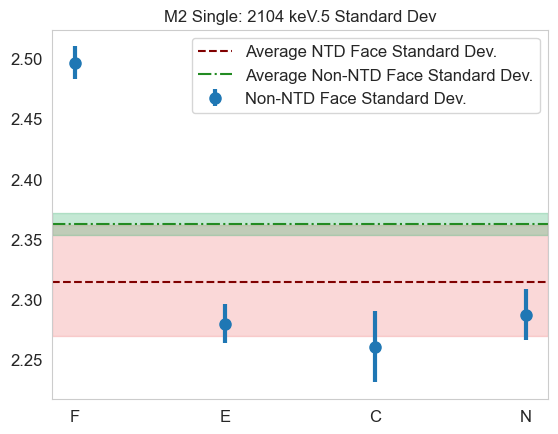

In [111]:
ax = plt.subplot()

topologies = ['F', 'E', "C", 'N']
sds = [Fsigma_fit, Esigma_fit, Csigma_fit, Nsigma_fit]

sds_intersections = [[Fintersection_sigma.geoms[0].x, Fintersection_sigma.geoms[1].x],[Eintersection_sigma.geoms[0].x, Eintersection_sigma.geoms[1].x],
                   [Cintersection_sigma.geoms[0].x, Cintersection_sigma.geoms[1].x], [Nintersection_sigma.geoms[0].x,Nintersection_sigma.geoms[1].x] ]

asymmetric_error = Errors(sds_intersections, sds)

ax.errorbar(topologies, sds, yerr=asymmetric_error, fmt='o', ms=8, elinewidth=3, label='Non-NTD Face Standard Dev.')
ax.axhspan(intersection_sigma.geoms[0].x, intersection_sigma.geoms[1].x, color='lightcoral', alpha=0.3)
ax.axhline(sigma_fit, color='maroon', linestyle='--', label='Average NTD Face Standard Dev.')

ax.axhspan(noNTDintersection_sigma.geoms[0].x, noNTDintersection_sigma.geoms[1].x, color='mediumseagreen', alpha=0.3)
ax.axhline(noNTDsigma_fit, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Standard Dev.')

ax.legend(fontsize=12)
ax.grid(False)
plt.xticks(fontsize=12);
plt.yticks(fontsize=12);
plt.title('M2 Single: 2104 keV.5 Standard Dev')

In [123]:
for i in range(len(means)):
    print(str(means[i]) + '-' + str(asymmetric_errormu[0][i]) + '+' + str(asymmetric_errormu[1][i]))
    
print(mu_fit)
print(mu_fit - intersection_mu.geoms[0].x)
print(mu_fit - intersection_mu.geoms[1].x)

print(noNTDmu_fit)
print(noNTDmu_fit - noNTDintersection_mu.geoms[0].x)
print(noNTDmu_fit - noNTDintersection_mu.geoms[1].x)

511.26383655038114-0.015783566056370546+0.01583442576924199
511.1273392025173-0.056252396121522+0.05626607375677395
511.1496157592808-0.053341470298505556+0.053310314203770304
511.0975747818384-0.05213592806398992+0.05216154603022005
511.1432558071038
0.05238831234339614
-0.05235317747718682
511.1457876728296
0.010228273677739708
-0.010226222185224287


In [114]:
for i in range(len(sds)):
    print(str(sds[i]) + '+' + str(asymmetric_error[0][i]) + '-' + str(asymmetric_error[1][i]))
    
print(sigma_fit)
print(sigma_fit - intersection_sigma.geoms[0].x)
print(sigma_fit - intersection_sigma.geoms[1].x)

print(noNTDsigma_fit)
print(noNTDsigma_fit - noNTDintersection_sigma.geoms[0].x)
print(noNTDsigma_fit - noNTDintersection_sigma.geoms[1].x)

2.4963205046069032+0.013660904404553253-0.013691572550953879
2.2797066201484997+0.015842293509483962-0.015999518047843164
2.259946465086519+0.029269763207565358-0.029810890764962128
2.2869969058061885+0.021390724066475908-0.02165444480347256
2.314581190318058
-0.046836043166773145
0.04493595966850705
2.3623378648676687
-0.008953512840773392
0.009033634962238413


Text(0.5, 1.0, 'Means Comparison: Binned vs Unbinned')

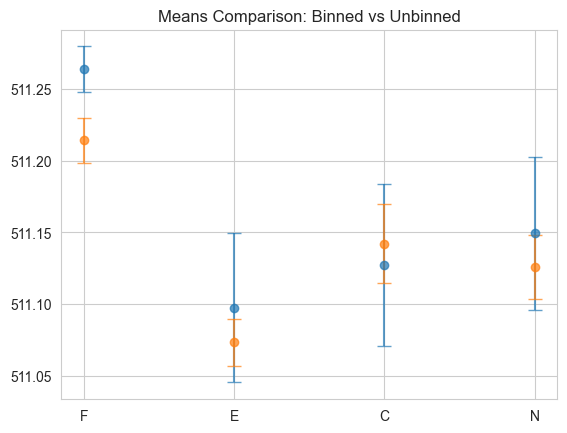

In [130]:
topologies = ['F', 'E', 'C', 'N']
means2 = [511.21420861553975, 511.0734598792555,511.1422402944534, 511.1257995817497]
y_err = [0.015606685614389028, 0.016476226003930762,0.02760376812585796, 0.022222617016052725]

ax = plt.subplot()
ax.errorbar(topologies, means, yerr=asymmetric_errormu, fmt='o', label='Unbinned', capsize=5, alpha=0.7)
ax.errorbar(topologies, means2, yerr=y_err, fmt='o', label='Binned', capsize=5, alpha=0.7)
ax.set_title('Means Comparison: Binned vs Unbinned')

Text(0.5, 1.0, 'Standard Dev Comparison: Binned vs Unbinned')

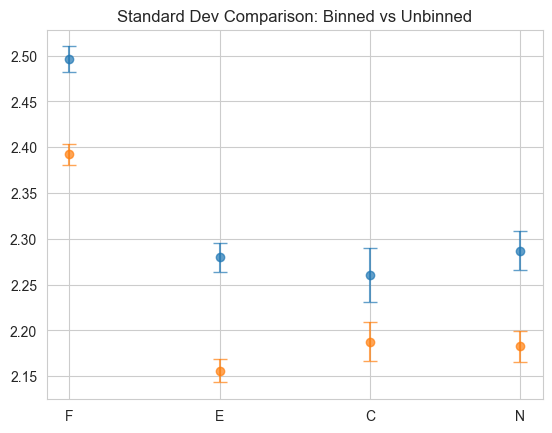

In [125]:
topologies = ['F', 'E', 'C', 'N']
sds2 = [2.3924179148390237, 2.1557142278338945, 2.1873214603244713, 2.182779495290293]
y_err = [0.011357069073590659, 0.012620057740448687, 0.02128770588627774, 0.016895894770445882]

ax = plt.subplot()
ax.errorbar(topologies, sds, yerr=asymmetric_error, capsize=5, alpha=0.7,fmt='o', label='Unbinned')
ax.errorbar(topologies, sds2, yerr=y_err, fmt='o',capsize=5, alpha=0.7, label='Binned')
ax.set_title('Standard Dev Comparison: Binned vs Unbinned')

In [ ]:
#### Error Analysis ##########

def AddSigmaToInt(x):
    s = f"{x:.1f}"
    if s.endswith("0"):
        s = f"{x:.0f}"
    return rf"{s} \-$\sigma$" if plt.rcParams["text.usetex"] else f"{s} -$\sigma$"

def AddSigmaToInt(x):
    sqrtx = np.sqrt(x)
    s = f"{sqrtx:.1f}"
    if s.endswith("0"):
        s = f"{sqrtx:.0f}"
    return f"{s}-$\\sigma$"

def LikelihoodGraphs2D(data, mu_fit, sigma_fit, b_fit, c_fit,d_fit, title, bplot=False):
    mus = np.linspace(mu_fit+1,mu_fit-1,50)
    sigmas = np.linspace(sigma_fit/2, sigma_fit*2,50)
    bs = np.linspace(b_fit/2, b_fit*2, 50)
    cs = np.linspace(c_fit/2, c_fit*2,50)
    ds = np.linspace(d_fit/2, d_fit*2,50)
    
    if bplot:
        
        muVals_meshgrid, sigmaVals_meshgrid = np.meshgrid(mus, sigmas)
        params_muVsigma = [muVals_meshgrid, sigmaVals_meshgrid, b_fit, c_fit, d_fit]
        ZmuVsigma = NegLogLikelihoodGuassLinear(params_muVsigma, data)
        ZmuVsigma_vals = ZmuVsigma - np.min(ZmuVsigma)
        
        fig, ax = plt.subplots(2,3, figsize=(15, 10))
        fig.suptitle(title, y=0.9)
        fig.tight_layout(pad=5.0)
        contour1 = ax[0,0].contourf(muVals_meshgrid, sigmaVals_meshgrid,ZmuVsigma_vals , 10, cmap='tab20b',linestyles ='None', alpha=0.7)
        CS = ax[0,0].contour(muVals_meshgrid, sigmaVals_meshgrid, ZmuVsigma_vals, levels=[0.0001, 1, 4, 9, 25, 100], cmap='Pastel1')

        ax[0,0].clabel(CS, CS.levels, inline=True, fmt=AddSigmaToInt, fontsize=10)
        ax[0,0].set_xlabel('$\mu$')
        ax[0,0].set_ylabel('$\sigma$')
        cbar1 = fig.colorbar(contour1, ax=ax[0,0])

        #plt.plot(mu, sigma, marker="o", markersize=10, markeredgecolor="cyan", markerfacecolor="blue", label='1D Loglikelihood') #this line does not apply since you already have data
        ax[0,0].plot(mu_fit, sigma_fit, marker="o", markersize=5, color="cyan", label='Best Fit Value')
        ax[0,0].set_title('Sigma vs Mu')
        # ax[0,0].set_xlim(2103,2105)
        # ax[0,0].set_ylim(2,4)
        
    ######################
    
        muVals_meshgrid, bVals_meshgrid = np.meshgrid(mus, bs)
        params_muVb= [muVals_meshgrid, sigma_fit, bVals_meshgrid, c_fit, d_fit]
        
        ZmuVb = NegLogLikelihoodGuassLinear(params_muVb, data)
        ZmuVb_vals = ZmuVb - np.min(ZmuVb)
        
        contour2 = ax[1,0].contourf(muVals_meshgrid, bVals_meshgrid, ZmuVb_vals, 100, cmap='tab20b',linestyles ='None', alpha=0.7)
        cbar2 = fig.colorbar(contour2, ax=ax[1,0])
        CS2 = ax[1,0].contour(muVals_meshgrid, bVals_meshgrid, ZmuVb_vals, levels=[0.0001, 1, 4, 9, 25, 100], cmap='Pastel1')

        ax[1,0].clabel(CS2, CS2.levels, inline=True, fmt=AddSigmaToInt, fontsize=10)
        plt.grid();
        ax[1,0].set_xlabel('$\mu$')
        ax[1,0].set_ylabel('$b = B/A$')

        #plt.plot(mu, sigma, marker="o", markersize=10, markeredgecolor="cyan", markerfacecolor="blue", label='1D Loglikelihood') #this line does not apply since you already have data
        ax[1,0].plot(mu_fit, b_fit, marker="o", markersize=5, color="cyan", label='Best Fit Value')
        ax[1,0].set_title('b vs Mu')
    ##################
    
        muVals_meshgrid, cVals_meshgrid = np.meshgrid(mus, cs)
        params_muVc= [muVals_meshgrid, sigma_fit, b_fit, cVals_meshgrid, d_fit]
        
        ZmuVc = NegLogLikelihoodGuassStepExp(params_muVc, data)
        ZmuVc_vals = ZmuVc - np.min(ZmuVc)
    
        contour3 = ax[1,1].contourf(muVals_meshgrid, cVals_meshgrid, ZmuVc_vals, 100, cmap='tab20b',linestyles ='None', alpha=0.7)
        cbar3 = fig.colorbar(contour3, ax=ax[1,1])
        CS3 = ax[1,1].contour(muVals_meshgrid, cVals_meshgrid, ZmuVc_vals, levels=[0.0001, 1, 4, 9, 25, 100], cmap='Pastel1')

        ax[1,1].clabel(CS3, CS3.levels, inline=True, fmt=AddSigmaToInt, fontsize=10)
        ax[1,1].set_xlabel('$\mu$')
        ax[1,1].set_ylabel('$c = C/A$')

        #plt.plot(mu, sigma, marker="o", markersize=10, markeredgecolor="cyan", markerfacecolor="blue", label='1D Loglikelihood') #this line does not apply since you already have data
        ax[1,1].plot(mu_fit, c_fit, marker="o", markersize=5, color="cyan", label='Best Fit Value')
        ax[1,1].set_title('c vs mu')
    ##############
    
        sigmaVals_meshgrid, bVals_meshgrid = np.meshgrid(sigmas, bs)
        params_sigmaVb= [mu_fit, sigmaVals_meshgrid, bVals_meshgrid, c_fit, d_fit]
        
        ZsigmaVb = NegLogLikelihoodGuassStepExp(params_sigmaVb, data)
        ZsigmaVb_vals = ZsigmaVb - np.min(ZsigmaVb)
        
        contour4 = ax[0,1].contourf(sigmaVals_meshgrid, bVals_meshgrid, ZsigmaVb_vals , 100, cmap='tab20b',linestyles ='None', alpha=0.7)
        cbar4 = fig.colorbar(contour4, ax=ax[0,1])
        CS4 = ax[0,1].contour(sigmaVals_meshgrid, bVals_meshgrid, ZsigmaVb_vals, levels=[0.0001, 1, 4, 9, 25, 100], cmap='Pastel1')

        ax[0,1].clabel(CS4, CS4.levels, inline=True, fmt=AddSigmaToInt, fontsize=10)
        ax[0,1].set_xlabel('$\sigma$')
        ax[0,1].set_ylabel('$b = B/A$')

        #plt.plot(mu, sigma, marker="o", markersize=10, markeredgecolor="cyan", markerfacecolor="blue", label='1D Loglikelihood') #this line does not apply since you already have data
        ax[0,1].plot(sigma_fit, b_fit, marker="o", markersize=5, color="cyan", label='Best Fit Value')
        ax[0,1].set_title('b vs Sigma')
    ##############
        sigmaVals_meshgrid, cVals_meshgrid = np.meshgrid(sigmas, cs)
        params_sigmaVc= [mu_fit, sigmaVals_meshgrid, b_fit, cVals_meshgrid, d_fit]
        
        ZsigmaVc = NegLogLikelihoodGuassStepExp(params_sigmaVc, data)
        ZsigmaVc_vals = ZsigmaVc - np.min(ZsigmaVc)
    
        contour5 = ax[0,2].contourf(sigmaVals_meshgrid, cVals_meshgrid, ZsigmaVc_vals, 100, cmap='tab20b',linestyles ='None', alpha=0.7)
        cbar5 = fig.colorbar(contour5, ax=ax[0,2])
        CS5 = ax[0,2].contour(sigmaVals_meshgrid, cVals_meshgrid, ZsigmaVc_vals, levels=[0.0001, 1, 4, 9, 25, 100], cmap='Pastel1')

        ax[0,2].clabel(CS5, CS5.levels, inline=True, fmt=AddSigmaToInt, fontsize=10)
        ax[0,2].set_xlabel('$\sigma$')
        ax[0,2].set_ylabel('$c = C/A$')

        #plt.plot(mu, sigma, marker="o", markersize=10, markeredgecolor="cyan", markerfacecolor="blue", label='1D Loglikelihood') #this line does not apply since you already have data
        ax[0,2].plot(sigma_fit, c_fit, marker="o", markersize=5, color="cyan", label='Best Fit Value')
        ax[0,2].set_title('c vs Sigma')
    ##############
        cVals_meshgrid, bVals_meshgrid = np.meshgrid(cs, bs)
        params_bVc= [mu_fit, sigma_fit, bVals_meshgrid, cVals_meshgrid, d_fit]
        
        ZbVc = NegLogLikelihoodGuassStepExp(params_bVc, data)
        ZbVc_vals = ZbVc - np.min(ZbVc)
    
        contour6 = ax[1,2].contourf(cVals_meshgrid, bVals_meshgrid,ZbVc_vals, 100, cmap='tab20b',linestyles ='None', alpha=0.7)
        cbar6 = fig.colorbar(contour6, ax=ax[1,2])
        CS6 = ax[1,2].contour(cVals_meshgrid, bVals_meshgrid, ZbVc_vals, levels=[0.0001, 1, 4, 9, 25, 100], cmap='Pastel1')

        ax[1,2].clabel(CS6, CS6.levels, inline=True, fmt=AddSigmaToInt, fontsize=10)
        ax[1,2].set_xlabel('$c = C/A$')
        ax[1,2].set_ylabel('$b = B/A$')

        #plt.plot(mu, sigma, marker="o", markersize=10, markeredgecolor="cyan", markerfacecolor="blue", label='1D Loglikelihood') #this line does not apply since you already have data
        ax[1,2].plot(c_fit, b_fit, marker="o", markersize=5, color="cyan", label='Best Fit Value')
        ax[1,2].set_title('c vs b')
        
        plt.show()